In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from exp_config import (
    d_in, d_out, seed, N, X_train, Y_train, X_test, Y_test, 
    tau, n_steps, lr_in, lr_out, q, batch_size, 
    last_particle_single_source, eval_every, ACTIVATION, num_repetitions, LOOP_SEED,
    BASE_SETTING_STR
    )

(8000, 784) (8000, 2) (2000, 784) (2000, 2)


In [3]:
df_results = pd.read_csv("plots/data_rms.csv")

In [4]:
# def plot_metric_vs_ML(
#     df,
#     metric='Delta_U',
#     variants=None,
#     methods=None,
#     log_x=False,
#     log_y=False,
#     fit_ml_inv_sqrt=False,
#     fit_ml_bounds=None,
#     fit_color='0.35',
#     fit_linestyle='--',
#     fit_alpha=0.9,
#     figsize=(7, 5),
#     show=True,
# ):
#     """Plot `metric` vs M*L on a single axis for all selected variants and methods.

#     Args:
#         df: pandas DataFrame containing columns ['D','L','M','M*L','variant','method',metric]
#         metric: string key to plot; must be one of 'Delta_U','Delta_V','Delta_h'
#         variants: list of variant names to include (defaults to all in df)
#         methods: list of methods to include (defaults to all in df)
#         log_x, log_y: whether to use log scale for axes
#         fit_ml_inv_sqrt: if True/False, apply to all variants. Can also be:
#                          - list of bools (one per variant, in same order as variants)
#                          - dict mapping variant names to bools
#         fit_ml_bounds: (lower, upper) bounds for M*L values to include in fit. Can be:
#                        - None (use all data)
#                        - tuple (lower, upper) to apply to all variants
#                        - dict mapping variant names to (lower, upper) tuples
#                        - list of (lower, upper) tuples, one per variant
#         fit_color: color used for the fit line when the series color is unavailable
#         fit_linestyle: linestyle used for the fit curve
#         fit_alpha: alpha used for the fit curve
#         figsize: tuple width,height for the figure
#         show: whether to plt.show() the figure

#     Returns:
#         matplotlib Figure
#     """
#     if metric not in ('Delta_U', 'Delta_V', 'Delta_h'):
#         raise ValueError("metric must be one of 'Delta_U','Delta_V','Delta_h'")

#     if variants is None:
#         variants = list(df['variant'].unique())
#     if methods is None:
#         methods = list(df['method'].unique())

#     # Normalize fit_ml_inv_sqrt to a dict mapping variant -> bool
#     if isinstance(fit_ml_inv_sqrt, bool):
#         fit_per_variant = {v: fit_ml_inv_sqrt for v in variants}
#     elif isinstance(fit_ml_inv_sqrt, dict):
#         fit_per_variant = fit_ml_inv_sqrt
#     elif isinstance(fit_ml_inv_sqrt, (list, tuple)):
#         if len(fit_ml_inv_sqrt) != len(variants):
#             raise ValueError(f"fit_ml_inv_sqrt list length ({len(fit_ml_inv_sqrt)}) must match variants length ({len(variants)})")
#         fit_per_variant = {v: f for v, f in zip(variants, fit_ml_inv_sqrt)}
#     else:
#         raise TypeError("fit_ml_inv_sqrt must be bool, list, tuple, or dict")

#     # Normalize fit_ml_bounds to a dict mapping variant -> (lower, upper)
#     if fit_ml_bounds is None:
#         bounds_per_variant = {v: (None, None) for v in variants}
#     elif isinstance(fit_ml_bounds, tuple) and len(fit_ml_bounds) == 2:
#         bounds_per_variant = {v: fit_ml_bounds for v in variants}
#     elif isinstance(fit_ml_bounds, dict):
#         bounds_per_variant = {v: fit_ml_bounds.get(v, (None, None)) for v in variants}
#     elif isinstance(fit_ml_bounds, (list, tuple)):
#         if len(fit_ml_bounds) != len(variants):
#             raise ValueError(f"fit_ml_bounds list length ({len(fit_ml_bounds)}) must match variants length ({len(variants)})")
#         bounds_per_variant = {v: b for v, b in zip(variants, fit_ml_bounds)}
#     else:
#         raise TypeError("fit_ml_bounds must be None, tuple, dict, or list")

#     fig, ax = plt.subplots(1, 1, figsize=figsize)

#     metric_label_map = {
#         'Delta_U': r'$\Delta U$',
#         'Delta_V': r'$\Delta V$',
#         'Delta_h': r'$\Delta h$',
#     }

#     variant_display_map = {
#         'full_unit_dropout': 'full-unit',
#         'stochastic_depth': 'stochastic-depth',
#         'single_source_M': 'depth_shared',
#     }
#     variant_color_map = {
#         'full_unit_dropout': 'tab:blue',
#         'stochastic_depth': 'tab:green',
#         'single_source_M': 'tab:purple',
#     }

#     markers = ['o', 's', '^', 'd', 'x', 'P', 'v']
#     has_any = False
#     for v_idx, variant in enumerate(variants):
#         variant_color = variant_color_map.get(variant, fit_color)
#         variant_label = variant_display_map.get(variant, variant)
#         should_fit = fit_per_variant.get(variant, False)
#         ml_lower, ml_upper = bounds_per_variant.get(variant, (None, None))
#         has_any = False
#         for m_idx, method in enumerate(methods):
#             subset = df[(df['variant'] == variant) & (df['method'] == method)].copy()
#             if subset.empty:
#                 continue
#             has_any = True
#             subset = subset.sort_values('M*L')
#             x = np.asarray(subset['M*L'].values)
#             y = np.asarray(subset[metric].values)
#             yerr = None
#             std_col = metric + '_std'
#             if std_col in subset.columns:
#                 yerr = subset[std_col].values

#             marker = markers[(v_idx + m_idx) % len(markers)]
#             label = f'{variant_label} / {method}'

#             ax.errorbar(
#                 x,
#                 y,
#                 yerr=yerr,
#                 marker=marker,
#                 color=variant_color,
#                 linestyle='-',
#                 label=label,
#                 capsize=4,
#                 markersize=6,
#             )

#             if should_fit:
#                 fit_mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
#                 if ml_lower is not None:
#                     fit_mask = fit_mask & (x >= ml_lower)
#                 if ml_upper is not None:
#                     fit_mask = fit_mask & (x <= ml_upper)
#                 if np.count_nonzero(fit_mask) >= 2:
#                     x_fit = x[fit_mask]
#                     y_fit = y[fit_mask]
#                     log_c = np.mean(np.log(y_fit) + 0.5 * np.log(x_fit))
#                     c = float(np.exp(log_c))
#                     x_line = np.geomspace(x_fit.min(), x_fit.max(), 200)
#                     y_line = c * x_line ** (-0.5)
#                     ax.plot(
#                         x_line,
#                         y_line,
#                         color=variant_color,
#                         linestyle=fit_linestyle,
#                         alpha=fit_alpha,
#                         linewidth=1.8,
#                         label=f'{variant_label} fit $(M L)^{{-1/2}}$',
#                     )

#     if not has_any:
#         ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)

#     ax.set_xlabel('M × L')
#     ax.set_ylabel(metric_label_map[metric])
#     ax.set_title(f'{metric_label_map[metric]} vs. effective model width (M x L)')
#     ax.grid(alpha=0.25, which='both')
#     ax.legend()

#     if log_x:
#         ax.set_xscale('log')
#     if log_y:
#         ax.set_yscale('log')

#     fig.tight_layout()
#     if show:
#         plt.show()
#     return fig
import numpy as np
import matplotlib.pyplot as plt


def plot_metric_vs_ML(
    df,
    metric='Delta_U',
    variants=None,
    methods=None,
    log_x=False,
    log_y=False,
    fit_ml_inv_sqrt=False,
    fit_ml_bounds=None,
    fit_color='0.35',
    fit_linestyle='--',
    fit_alpha=0.9,
    aggregate_duplicates=True,
    std_combine='quadrature',
    figsize=(7, 5),
    show=True,
):
    """Plot `metric` vs M*L on a single axis for all selected variants and methods.

    Args:
        df: pandas DataFrame containing columns ['D','L','M','M*L','variant','method',metric]
        metric: string key to plot; must be one of 'Delta_U','Delta_V','Delta_h'
        variants: list of variant names to include (defaults to all in df)
        methods: list of methods to include (defaults to all in df)
        log_x, log_y: whether to use log scale for axes
        fit_ml_inv_sqrt: if True/False, apply to all variants. Can also be:
                         - list of bools (one per variant, in same order as variants)
                         - dict mapping variant names to bools
        fit_ml_bounds: (lower, upper) bounds for M*L values to include in fit. Can be:
                       - None (use all data)
                       - tuple (lower, upper) to apply to all variants
                       - dict mapping variant names to (lower, upper) tuples
                       - list of (lower, upper) tuples, one per variant
        fit_color: color used for the fit line when the series color is unavailable
        fit_linestyle: linestyle used for the fit curve
        fit_alpha: alpha used for the fit curve
        aggregate_duplicates: if True (default), rows sharing the same M*L value
                              within a given (variant, method) group are collapsed
                              into a single point before plotting and before
                              fitting. The metric is averaged (mean); the std
                              column (if present) is combined according to
                              `std_combine`. Set to False to restore the previous
                              behavior of plotting every row independently.
        std_combine: how to combine multiple std values that land on the same
                     M*L value after aggregation. One of:
                       - 'quadrature': sqrt(mean(std**2))  (default, statistically
                         sensible when combining independent estimates of spread)
                       - 'mean': simple average of the std values
        figsize: tuple width,height for the figure
        show: whether to plt.show() the figure

    Returns:
        matplotlib Figure
    """
    if metric not in ('Delta_U', 'Delta_V', 'Delta_h'):
        raise ValueError("metric must be one of 'Delta_U','Delta_V','Delta_h'")

    if std_combine not in ('quadrature', 'mean'):
        raise ValueError("std_combine must be one of 'quadrature', 'mean'")

    if variants is None:
        variants = list(df['variant'].unique())
    if methods is None:
        methods = list(df['method'].unique())

    # Normalize fit_ml_inv_sqrt to a dict mapping variant -> bool
    if isinstance(fit_ml_inv_sqrt, bool):
        fit_per_variant = {v: fit_ml_inv_sqrt for v in variants}
    elif isinstance(fit_ml_inv_sqrt, dict):
        fit_per_variant = fit_ml_inv_sqrt
    elif isinstance(fit_ml_inv_sqrt, (list, tuple)):
        if len(fit_ml_inv_sqrt) != len(variants):
            raise ValueError(f"fit_ml_inv_sqrt list length ({len(fit_ml_inv_sqrt)}) must match variants length ({len(variants)})")
        fit_per_variant = {v: f for v, f in zip(variants, fit_ml_inv_sqrt)}
    else:
        raise TypeError("fit_ml_inv_sqrt must be bool, list, tuple, or dict")

    # Normalize fit_ml_bounds to a dict mapping variant -> (lower, upper)
    if fit_ml_bounds is None:
        bounds_per_variant = {v: (None, None) for v in variants}
    elif isinstance(fit_ml_bounds, tuple) and len(fit_ml_bounds) == 2:
        bounds_per_variant = {v: fit_ml_bounds for v in variants}
    elif isinstance(fit_ml_bounds, dict):
        bounds_per_variant = {v: fit_ml_bounds.get(v, (None, None)) for v in variants}
    elif isinstance(fit_ml_bounds, (list, tuple)):
        if len(fit_ml_bounds) != len(variants):
            raise ValueError(f"fit_ml_bounds list length ({len(fit_ml_bounds)}) must match variants length ({len(variants)})")
        bounds_per_variant = {v: b for v, b in zip(variants, fit_ml_bounds)}
    else:
        raise TypeError("fit_ml_bounds must be None, tuple, dict, or list")

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    metric_label_map = {
        'Delta_U': r'$\Delta U$',
        'Delta_V': r'$\Delta V$',
        'Delta_h': r'$\Delta h$',
    }

    variant_display_map = {
        'full_unit_dropout': 'full-unit',
        'stochastic_depth': 'stochastic-depth',
        'single_source_M': 'depth_shared',
    }
    variant_color_map = {
        'full_unit_dropout': 'tab:blue',
        'stochastic_depth': 'tab:green',
        'single_source_M': 'tab:purple',
    }

    markers = ['o', 's', '^', 'd', 'x', 'P', 'v']

    def _aggregate_subset(subset):
        """Collapse rows sharing the same M*L value into a single point.

        Averages `metric` across duplicates; combines the std column (if
        present) according to `std_combine`. Returns (x, y, yerr) arrays,
        sorted by M*L.
        """
        std_col = metric + '_std'
        has_std = std_col in subset.columns

        if std_combine == 'quadrature':
            std_agg = lambda s: float(np.sqrt(np.mean(np.square(np.asarray(s, dtype=float)))))
        else:  # 'mean'
            std_agg = 'mean'

        agg_dict = {metric: 'mean'}
        if has_std:
            agg_dict[std_col] = std_agg

        grouped = subset.groupby('M*L', as_index=False).agg(agg_dict)
        grouped = grouped.sort_values('M*L')

        x = np.asarray(grouped['M*L'].values)
        y = np.asarray(grouped[metric].values)
        yerr = np.asarray(grouped[std_col].values) if has_std else None
        return x, y, yerr

    has_any = False
    for v_idx, variant in enumerate(variants):
        variant_color = variant_color_map.get(variant, fit_color)
        variant_label = variant_display_map.get(variant, variant)
        should_fit = fit_per_variant.get(variant, False)
        ml_lower, ml_upper = bounds_per_variant.get(variant, (None, None))
        has_any = False
        for m_idx, method in enumerate(methods):
            subset = df[(df['variant'] == variant) & (df['method'] == method)].copy()
            if subset.empty:
                continue
            has_any = True

            if aggregate_duplicates:
                x, y, yerr = _aggregate_subset(subset)
            else:
                subset = subset.sort_values('M*L')
                x = np.asarray(subset['M*L'].values)
                y = np.asarray(subset[metric].values)
                yerr = None
                std_col = metric + '_std'
                if std_col in subset.columns:
                    yerr = subset[std_col].values

            marker = markers[(v_idx + m_idx) % len(markers)]
            label = f'{variant_label} / {method}'

            ax.errorbar(
                x,
                y,
                yerr=yerr,
                marker=marker,
                color=variant_color,
                linestyle='-',
                label=label,
                capsize=4,
                markersize=6,
            )

            if should_fit:
                fit_mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
                if ml_lower is not None:
                    fit_mask = fit_mask & (x >= ml_lower)
                if ml_upper is not None:
                    fit_mask = fit_mask & (x <= ml_upper)
                if np.count_nonzero(fit_mask) >= 2:
                    x_fit = x[fit_mask]
                    y_fit = y[fit_mask]
                    log_c = np.mean(np.log(y_fit) + 0.5 * np.log(x_fit))
                    c = float(np.exp(log_c))
                    x_line = np.geomspace(x_fit.min(), x_fit.max(), 200)
                    y_line = c * x_line ** (-0.5)
                    ax.plot(
                        x_line,
                        y_line,
                        color=variant_color,
                        linestyle=fit_linestyle,
                        alpha=fit_alpha,
                        linewidth=1.8,
                        label=f'{variant_label} fit $(M L)^{{-1/2}}$',
                    )

    if not has_any:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)

    ax.set_xlabel('M × L')
    ax.set_ylabel(metric_label_map[metric])
    ax.set_title(f'{metric_label_map[metric]} vs. effective model width (M x L)')
    ax.grid(alpha=0.25, which='both')
    ax.legend()

    if log_x:
        ax.set_xscale('log')
    if log_y:
        ax.set_yscale('log')

    fig.tight_layout()
    if show:
        plt.show()
    return fig

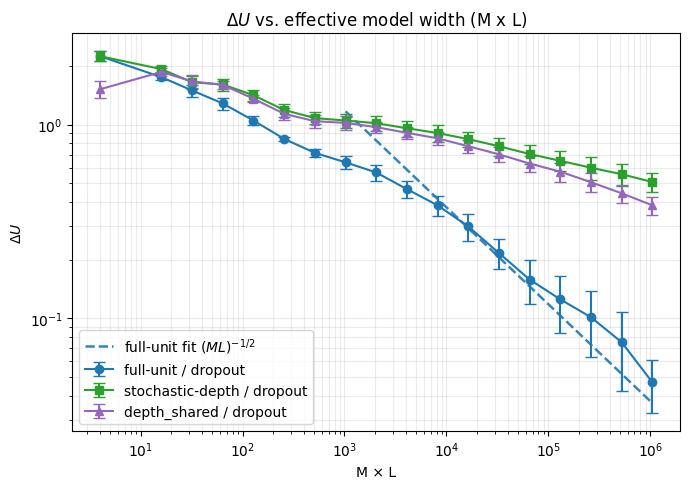

In [5]:
figU = plot_metric_vs_ML(df_results, metric='Delta_U', log_x=True, log_y=True, fit_ml_inv_sqrt=[True, False, False], fit_ml_bounds=(1000, 10000000))

In [6]:
figU.savefig("plots/Delta_U_vs_ML.pdf")

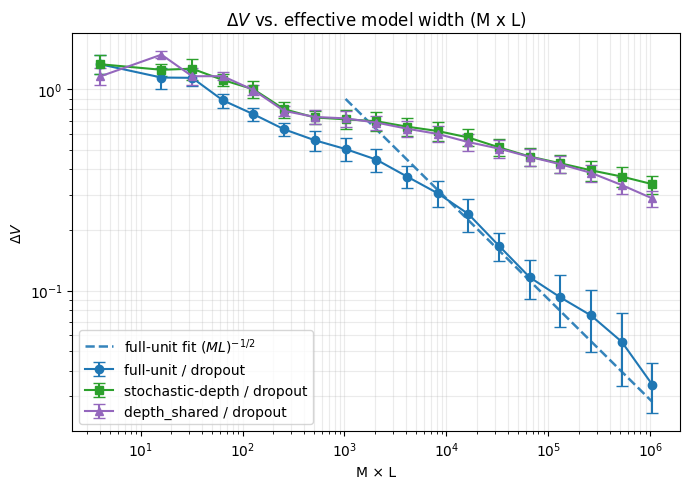

In [7]:
figV = plot_metric_vs_ML(df_results, metric='Delta_V', log_x=True, log_y=True, fit_ml_inv_sqrt=[True, False, False], fit_ml_bounds=(1000, 10000000))

In [8]:
figV.savefig("plots/Delta_V_vs_ML.pdf")

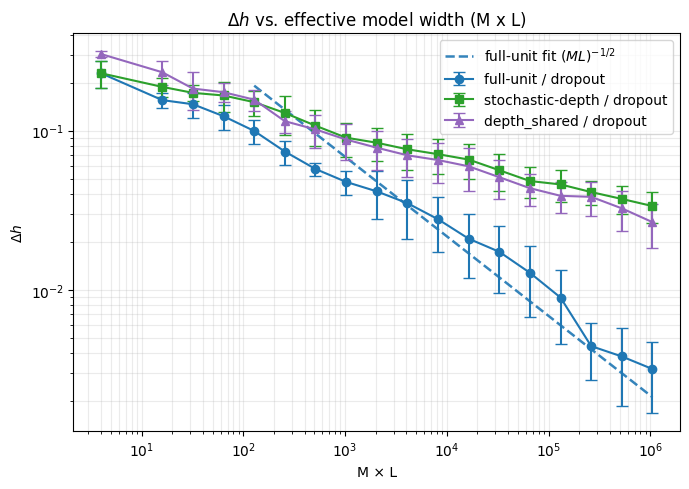

In [9]:
figh = plot_metric_vs_ML(df_results, metric='Delta_h', log_x=True, log_y=True, fit_ml_inv_sqrt=[True, False, False], fit_ml_bounds=(100, 10000000))

In [10]:
figh.savefig("plots/Delta_h_vs_ML.pdf")

In [11]:
# import numpy as np
# import matplotlib.pyplot as plt


# def plot_metric_vs_ML2(
#     df,
#     metric='Delta_U',
#     variants=None,
#     methods=None,
#     log_x=False,
#     log_y=False,
#     fit_ml_inv_sqrt=False,
#     fit_ml_bounds=None,
#     fit_color='0.35',
#     fit_linestyle='--',
#     fit_alpha=0.9,
#     figsize=(12, 5),
#     show=True,
# ):
#     """Plot `metric` vs M and vs L, side by side, for all selected variants and methods.

#     Args:
#         df: pandas DataFrame containing columns ['D','L','M','M*L','variant','method',metric]
#         metric: string key to plot; must be one of 'Delta_U','Delta_V','Delta_h'
#         variants: list of variant names to include (defaults to all in df)
#         methods: list of methods to include (defaults to all in df)
#         log_x, log_y: whether to use log scale for axes (applied to both subplots)
#         fit_ml_inv_sqrt: if True/False, apply to all variants. Can also be:
#                          - list of bools (one per variant, in same order as variants)
#                          - dict mapping variant names to bools
#         fit_ml_bounds: (lower, upper) bounds for the x-axis values to include in fit
#                        (bounds are applied independently on each subplot's own x column).
#                        Can be:
#                        - None (use all data)
#                        - tuple (lower, upper) to apply to all variants
#                        - dict mapping variant names to (lower, upper) tuples
#                        - list of (lower, upper) tuples, one per variant
#         fit_color: color used for the fit line when the series color is unavailable
#         fit_linestyle: linestyle used for the fit curve
#         fit_alpha: alpha used for the fit curve
#         figsize: tuple width,height for the whole figure (two subplots)
#         show: whether to plt.show() the figure

#     Returns:
#         matplotlib Figure
#     """
#     if metric not in ('Delta_U', 'Delta_V', 'Delta_h'):
#         raise ValueError("metric must be one of 'Delta_U','Delta_V','Delta_h'")

#     if variants is None:
#         variants = list(df['variant'].unique())
#     if methods is None:
#         methods = list(df['method'].unique())

#     # Normalize fit_ml_inv_sqrt to a dict mapping variant -> bool
#     if isinstance(fit_ml_inv_sqrt, bool):
#         fit_per_variant = {v: fit_ml_inv_sqrt for v in variants}
#     elif isinstance(fit_ml_inv_sqrt, dict):
#         fit_per_variant = fit_ml_inv_sqrt
#     elif isinstance(fit_ml_inv_sqrt, (list, tuple)):
#         if len(fit_ml_inv_sqrt) != len(variants):
#             raise ValueError(f"fit_ml_inv_sqrt list length ({len(fit_ml_inv_sqrt)}) must match variants length ({len(variants)})")
#         fit_per_variant = {v: f for v, f in zip(variants, fit_ml_inv_sqrt)}
#     else:
#         raise TypeError("fit_ml_inv_sqrt must be bool, list, tuple, or dict")

#     # Normalize fit_ml_bounds to a dict mapping variant -> (lower, upper)
#     if fit_ml_bounds is None:
#         bounds_per_variant = {v: (None, None) for v in variants}
#     elif isinstance(fit_ml_bounds, tuple) and len(fit_ml_bounds) == 2:
#         bounds_per_variant = {v: fit_ml_bounds for v in variants}
#     elif isinstance(fit_ml_bounds, dict):
#         bounds_per_variant = {v: fit_ml_bounds.get(v, (None, None)) for v in variants}
#     elif isinstance(fit_ml_bounds, (list, tuple)):
#         if len(fit_ml_bounds) != len(variants):
#             raise ValueError(f"fit_ml_bounds list length ({len(fit_ml_bounds)}) must match variants length ({len(variants)})")
#         bounds_per_variant = {v: b for v, b in zip(variants, fit_ml_bounds)}
#     else:
#         raise TypeError("fit_ml_bounds must be None, tuple, dict, or list")

#     metric_label_map = {
#         'Delta_U': r'$\Delta U$',
#         'Delta_V': r'$\Delta V$',
#         'Delta_h': r'$\Delta h$',
#     }

#     variant_display_map = {
#         'full_unit_dropout': 'full-unit',
#         'stochastic_depth': 'stochastic-depth',
#         'single_source_M': 'depth_shared',
#     }
#     variant_color_map = {
#         'full_unit_dropout': 'tab:blue',
#         'stochastic_depth': 'tab:green',
#         'single_source_M': 'tab:purple',
#     }

#     markers = ['o', 's', '^', 'd', 'x', 'P', 'v']

#     # The two panels: (x_column, x_axis_label)
#     panels = [
#         ('M', 'M'),
#         ('L', 'L'),
#     ]

#     fig, axes = plt.subplots(1, 2, figsize=figsize)

#     def _plot_panel(ax, x_col, x_label):
#         has_any = False
#         for v_idx, variant in enumerate(variants):
#             variant_color = variant_color_map.get(variant, fit_color)
#             variant_label = variant_display_map.get(variant, variant)
#             should_fit = fit_per_variant.get(variant, False)
#             x_lower, x_upper = bounds_per_variant.get(variant, (None, None))
#             for m_idx, method in enumerate(methods):
#                 subset = df[(df['variant'] == variant) & (df['method'] == method)].copy()
#                 if subset.empty:
#                     continue
#                 has_any = True
#                 subset = subset.sort_values(x_col)
#                 x = np.asarray(subset[x_col].values)
#                 y = np.asarray(subset[metric].values)
#                 yerr = None
#                 std_col = metric + '_std'
#                 if std_col in subset.columns:
#                     yerr = subset[std_col].values

#                 marker = markers[(v_idx + m_idx) % len(markers)]
#                 label = f'{variant_label} / {method}'

#                 ax.errorbar(
#                     x,
#                     y,
#                     yerr=yerr,
#                     marker=marker,
#                     color=variant_color,
#                     linestyle='-',
#                     label=label,
#                     capsize=4,
#                     markersize=6,
#                 )

#                 if should_fit:
#                     fit_mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
#                     if x_lower is not None:
#                         fit_mask = fit_mask & (x >= x_lower)
#                     if x_upper is not None:
#                         fit_mask = fit_mask & (x <= x_upper)
#                     if np.count_nonzero(fit_mask) >= 2:
#                         x_fit = x[fit_mask]
#                         y_fit = y[fit_mask]
#                         log_c = np.mean(np.log(y_fit) + 0.5 * np.log(x_fit))
#                         c = float(np.exp(log_c))
#                         x_line = np.geomspace(x_fit.min(), x_fit.max(), 200)
#                         y_line = c * x_line ** (-0.5)
#                         ax.plot(
#                             x_line,
#                             y_line,
#                             color=variant_color,
#                             linestyle=fit_linestyle,
#                             alpha=fit_alpha,
#                             linewidth=1.8,
#                             label=f'{variant_label} fit ${x_label}^{{-1/2}}$',
#                         )

#         if not has_any:
#             ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)

#         ax.set_xlabel(x_label)
#         ax.set_ylabel(metric_label_map[metric])
#         ax.set_title(f'{metric_label_map[metric]} vs. {x_label}')
#         ax.grid(alpha=0.25, which='both')
#         ax.legend()

#         if log_x:
#             ax.set_xscale('log')
#         if log_y:
#             ax.set_yscale('log')

#     for ax, (x_col, x_label) in zip(axes, panels):
#         _plot_panel(ax, x_col, x_label)

#     fig.tight_layout()
#     if show:
#         plt.show()
#     return fig

In [12]:
import numpy as np
import matplotlib.pyplot as plt


def plot_metric_vs_ML2(
    df,
    metric='Delta_U',
    variants=None,
    methods=None,
    log_x=False,
    log_y=False,
    fit_ml_inv_sqrt=False,
    fit_ml_bounds=None,
    fit_color='0.35',
    fit_linestyle='--',
    fit_alpha=0.9,
    aggregate_duplicates=True,
    std_combine='quadrature',
    figsize=(12, 5),
    show=True,
):
    """Plot `metric` vs M and vs L, side by side, for all selected variants and methods.

    Args:
        df: pandas DataFrame containing columns ['D','L','M','M*L','variant','method',metric]
        metric: string key to plot; must be one of 'Delta_U','Delta_V','Delta_h'
        variants: list of variant names to include (defaults to all in df)
        methods: list of methods to include (defaults to all in df)
        log_x, log_y: whether to use log scale for axes (applied to both subplots)
        fit_ml_inv_sqrt: if True/False, apply to all variants. Can also be:
                         - list of bools (one per variant, in same order as variants)
                         - dict mapping variant names to bools
        fit_ml_bounds: (lower, upper) bounds for the x-axis values to include in fit
                       (bounds are applied independently on each subplot's own x column).
                       Can be:
                       - None (use all data)
                       - tuple (lower, upper) to apply to all variants
                       - dict mapping variant names to (lower, upper) tuples
                       - list of (lower, upper) tuples, one per variant
        fit_color: color used for the fit line when the series color is unavailable
        fit_linestyle: linestyle used for the fit curve
        fit_alpha: alpha used for the fit curve
        aggregate_duplicates: if True (default), rows sharing the same x-axis value
                              (M in the left panel, L in the right panel) within a
                              given (variant, method) group are collapsed into a
                              single point before plotting and before fitting. The
                              metric is averaged (mean); the std column (if present)
                              is combined according to `std_combine`. This is done
                              independently per panel, since the M panel and the L
                              panel can have different notions of "duplicate" (e.g.
                              several L values sharing an M, or several D values
                              sharing an (L, M) pair). Set to False to restore the
                              previous behavior of plotting every row independently.
        std_combine: how to combine multiple std values that land on the same x
                     after aggregation. One of:
                       - 'quadrature': sqrt(mean(std**2))  (default, statistically
                         sensible when combining independent estimates of spread)
                       - 'mean': simple average of the std values
        figsize: tuple width,height for the whole figure (two subplots)
        show: whether to plt.show() the figure

    Returns:
        matplotlib Figure
    """
    if metric not in ('Delta_U', 'Delta_V', 'Delta_h'):
        raise ValueError("metric must be one of 'Delta_U','Delta_V','Delta_h'")

    if std_combine not in ('quadrature', 'mean'):
        raise ValueError("std_combine must be one of 'quadrature', 'mean'")

    if variants is None:
        variants = list(df['variant'].unique())
    if methods is None:
        methods = list(df['method'].unique())

    # Normalize fit_ml_inv_sqrt to a dict mapping variant -> bool
    if isinstance(fit_ml_inv_sqrt, bool):
        fit_per_variant = {v: fit_ml_inv_sqrt for v in variants}
    elif isinstance(fit_ml_inv_sqrt, dict):
        fit_per_variant = fit_ml_inv_sqrt
    elif isinstance(fit_ml_inv_sqrt, (list, tuple)):
        if len(fit_ml_inv_sqrt) != len(variants):
            raise ValueError(f"fit_ml_inv_sqrt list length ({len(fit_ml_inv_sqrt)}) must match variants length ({len(variants)})")
        fit_per_variant = {v: f for v, f in zip(variants, fit_ml_inv_sqrt)}
    else:
        raise TypeError("fit_ml_inv_sqrt must be bool, list, tuple, or dict")

    # Normalize fit_ml_bounds to a dict mapping variant -> (lower, upper)
    if fit_ml_bounds is None:
        bounds_per_variant = {v: (None, None) for v in variants}
    elif isinstance(fit_ml_bounds, tuple) and len(fit_ml_bounds) == 2:
        bounds_per_variant = {v: fit_ml_bounds for v in variants}
    elif isinstance(fit_ml_bounds, dict):
        bounds_per_variant = {v: fit_ml_bounds.get(v, (None, None)) for v in variants}
    elif isinstance(fit_ml_bounds, (list, tuple)):
        if len(fit_ml_bounds) != len(variants):
            raise ValueError(f"fit_ml_bounds list length ({len(fit_ml_bounds)}) must match variants length ({len(variants)})")
        bounds_per_variant = {v: b for v, b in zip(variants, fit_ml_bounds)}
    else:
        raise TypeError("fit_ml_bounds must be None, tuple, dict, or list")

    metric_label_map = {
        'Delta_U': r'$\Delta U$',
        'Delta_V': r'$\Delta V$',
        'Delta_h': r'$\Delta h$',
    }

    variant_display_map = {
        'full_unit_dropout': 'full-unit',
        'stochastic_depth': 'stochastic-depth',
        'single_source_M': 'depth_shared',
    }
    variant_color_map = {
        'full_unit_dropout': 'tab:blue',
        'stochastic_depth': 'tab:green',
        'single_source_M': 'tab:purple',
    }

    markers = ['o', 's', '^', 'd', 'x', 'P', 'v']

    # The two panels: (x_column, x_axis_label)
    panels = [
        ('M', 'M'),
        ('L', 'L'),
    ]

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    def _aggregate_subset(subset, x_col):
        """Collapse rows sharing the same x_col value into a single point.

        Averages `metric` across duplicates; combines the std column (if
        present) according to `std_combine`. Returns (x, y, yerr) arrays,
        sorted by x_col.
        """
        std_col = metric + '_std'
        has_std = std_col in subset.columns

        if std_combine == 'quadrature':
            std_agg = lambda s: float(np.sqrt(np.mean(np.square(np.asarray(s, dtype=float)))))
        else:  # 'mean'
            std_agg = 'mean'

        agg_dict = {metric: 'mean'}
        if has_std:
            agg_dict[std_col] = std_agg

        grouped = subset.groupby(x_col, as_index=False).agg(agg_dict)
        grouped = grouped.sort_values(x_col)

        x = np.asarray(grouped[x_col].values)
        y = np.asarray(grouped[metric].values)
        yerr = np.asarray(grouped[std_col].values) if has_std else None
        return x, y, yerr

    def _plot_panel(ax, x_col, x_label):
        has_any = False
        for v_idx, variant in enumerate(variants):
            variant_color = variant_color_map.get(variant, fit_color)
            variant_label = variant_display_map.get(variant, variant)
            should_fit = fit_per_variant.get(variant, False)
            if variant == 'single_source_M' and x_col == 'L':
                # For single_source_M, only independence in M.
                should_fit = False
            if variant == 'stochastic_depth' and x_col == 'M':
                # For stochastic_depth, only independence in L.
                should_fit = False
            x_lower, x_upper = bounds_per_variant.get(variant, (None, None))
            for m_idx, method in enumerate(methods):
                subset = df[(df['variant'] == variant) & (df['method'] == method)].copy()
                if subset.empty:
                    continue
                has_any = True

                if aggregate_duplicates:
                    x, y, yerr = _aggregate_subset(subset, x_col)
                else:
                    subset = subset.sort_values(x_col)
                    x = np.asarray(subset[x_col].values)
                    y = np.asarray(subset[metric].values)
                    yerr = None
                    std_col = metric + '_std'
                    if std_col in subset.columns:
                        yerr = subset[std_col].values

                marker = markers[(v_idx + m_idx) % len(markers)]
                label = f'{variant_label} / {method}'

                ax.errorbar(
                    x,
                    y,
                    yerr=yerr,
                    marker=marker,
                    color=variant_color,
                    linestyle='-',
                    label=label,
                    capsize=4,
                    markersize=6,
                )

                if should_fit:
                    fit_mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
                    if x_lower is not None:
                        fit_mask = fit_mask & (x >= x_lower)
                    if x_upper is not None:
                        fit_mask = fit_mask & (x <= x_upper)
                    if np.count_nonzero(fit_mask) >= 2:
                        x_fit = x[fit_mask]
                        y_fit = y[fit_mask]
                        log_c = np.mean(np.log(y_fit) + 0.5 * np.log(x_fit))
                        c = float(np.exp(log_c))
                        x_line = np.geomspace(x_fit.min(), x_fit.max(), 200)
                        y_line = c * x_line ** (-0.5)
                        ax.plot(
                            x_line,
                            y_line,
                            color=variant_color,
                            linestyle=fit_linestyle,
                            alpha=fit_alpha,
                            linewidth=1.8,
                            label=f'{variant_label} fit ${x_label}^{{-1/2}}$',
                        )

        if not has_any:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)

        ax.set_xlabel(x_label)
        ax.set_ylabel(metric_label_map[metric])
        ax.set_title(f'{metric_label_map[metric]} vs. {x_label}')
        ax.grid(alpha=0.25, which='both')
        ax.legend()

        if log_x:
            ax.set_xscale('log')
        if log_y:
            ax.set_yscale('log')

    for ax, (x_col, x_label) in zip(axes, panels):
        _plot_panel(ax, x_col, x_label)

    fig.tight_layout()
    if show:
        plt.show()
    return fig

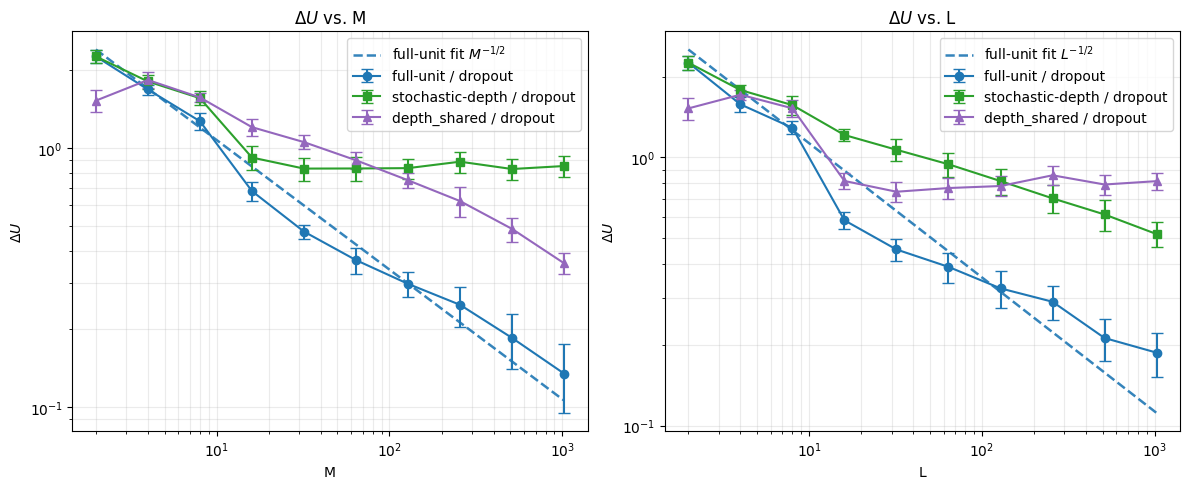

In [13]:
figU2 = plot_metric_vs_ML2(df_results, metric='Delta_U', log_x=True, log_y=True, fit_ml_inv_sqrt=[True, False, False])

In [14]:
figU2.savefig("plots/Delta_U_vs_M_and_L.pdf")

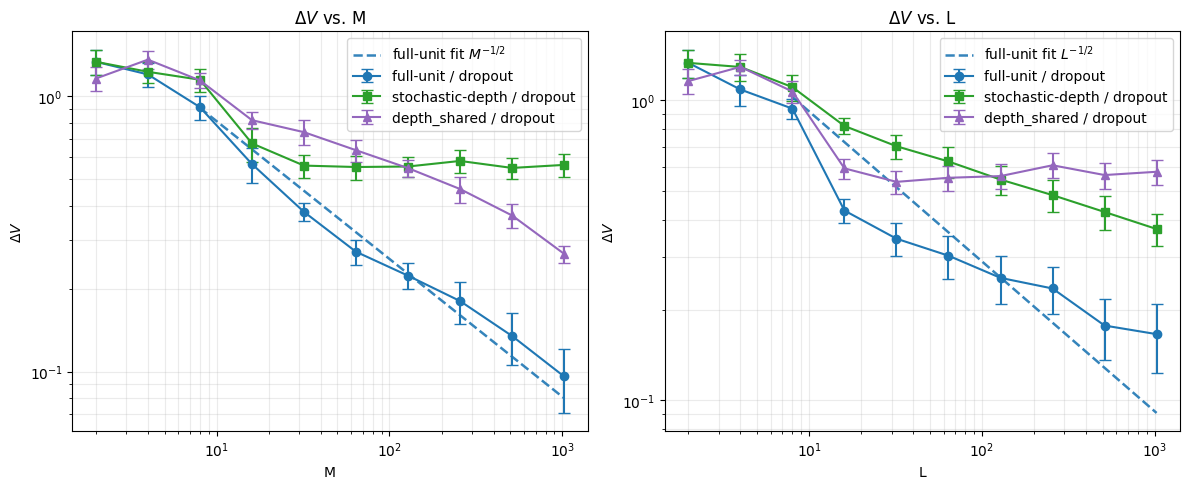

In [15]:
figV2 = plot_metric_vs_ML2(df_results, metric='Delta_V', log_x=True, log_y=True, fit_ml_inv_sqrt=[True, False, False], fit_ml_bounds=[(8, 10000000), (8, 1000000), (8, 10000000)])

In [16]:
figV2.savefig("plots/Delta_V_vs_M_and_L.pdf")

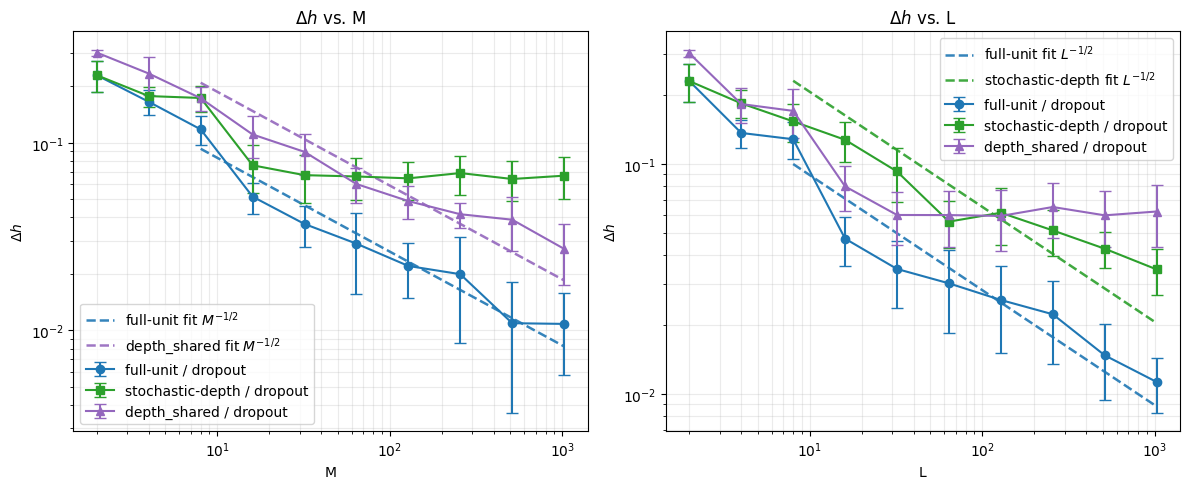

In [17]:
figh2 = plot_metric_vs_ML2(df_results, metric='Delta_h', log_x=True, log_y=True, fit_ml_inv_sqrt=[True, True, True], fit_ml_bounds=[(8, 10000000), (8, 1000000), (8, 10000000)])

In [18]:
figh2.savefig("plots/Delta_h_vs_M_and_L.pdf")